# Visium HD 3' (peak-based)

This notebook demonstrates a spatial transcriptome 3' end diversity (TREND) workflow on **3' Visium HD peak-level data**:

1. Load preprocessed peak-level `SpatialData` from a `.zarr` store.
2. Visualize peak-level expression and within-gene ratios.
3. Run FFT-accelerated spatial variability tests with `SplisosmFFT`.
4. Compare results across spatial resolutions and with `SplisosmNP`.

Estimated runtime: ~20 min.

## Preliminary notes

3' end sequencing data allows us to investigate variation near the 3' end of transcripts, which we refer to as transcriptome 3' end diversity (TREND) events. For the analysis, we first call junction-aware peaks from the BAM file using [Sierra](https://github.com/VCCRI/Sierra), then quantify peak-level expression in each Visium HD bin using [UMI-tools](https://umi-tools.readthedocs.io/en/latest/index.html). An example workflow is provided in `scripts/visiumhd_3p_trend_quant.sh` under the [scripts directory](https://github.com/JiayuSuPKU/SPLISOSM/tree/main/scripts), which generates a peak-level `SpatialData` object stored as a `.zarr` file.

`SplisosmFFT` and `SplisosmNP` both implement the same HSIC-based spatial variability test but with different approaches: FFT uses full-rank kernels on regular grids (faster for large datasets); NP uses low-rank kernel approximation, compatible with irregular geometries such as cell-segmented data. For data on a regular grid — like Visium HD bins — `SplisosmFFT` is recommended. See the [API documentation](https://splisosm.readthedocs.io/en/latest/autoapi/splisosm/hyptest_fft/index.html) and [associated preprint](https://arxiv.org/pdf/2602.02825) for technical details.

## Imports

In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import warnings

import annsel as an
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import spatialdata as sd
import spatialdata_plot
from spatialdata import rasterize_bins

from splisosm import SplisosmFFT, SplisosmNP
from splisosm.utils import counts_to_ratios

/Users/jysumac/miniforge3/envs/splisosm_test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (6, 4)

## Configure paths and core parameters

In [38]:
# Path to the preprocessed peak-level SpatialData zarr
sdata_zarr = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_3p_mouse_cbs/sdata_peak.filtered.zarr")

# Dataset and table identifiers (16um binning used throughout)
dataset_id = ""
test_table = "square_016um"
test_bins_element = f"{dataset_id}_square_016um"

# Peak annotation column names
group_iso_by = "gene_ids"
gene_name_col = "gene_ids"
candidate_gene_name_cols = ["gene_name", "gene_ids", "gene_symbol", "gene_names"]

# Peak QC filters
min_counts = 10
min_bin_pct = 0.01

## Load preprocessed peak-level `SpatialData`

We use a [Visium HD 3' mouse brain dataset](https://www.10xgenomics.com/datasets/visium-hd-three-prime-mouse-brain-fresh-frozen) from 10x Genomics (Fresh Frozen). Here we load the preprocessed peak-level `SpatialData` generated from the custom quantification workflow in `scripts/visiumhd_3p_trend_quant.sh`. Sierra peak quantification is stored at `outs/binned_outputs/square_002um/raw_probe_bc_matrix.h5`.

In [ ]:
%%time
if sdata_zarr.exists():
    print("Loading preprocessed SpatialData...")
    sdata = sd.read_zarr(sdata_zarr)
else:
    print("Building peak-level SpatialData from quantification outputs...")
    from splisosm.io import load_visiumhd_peak
    sdata = load_visiumhd_peak(
        path='path/to/outs',
        bin_sizes=bin_sizes,
        filtered_counts_file=True,
        load_all_images=False,
        var_names_make_unique=True,
        counts_layer_name="counts",
    )
    # Optional: cache for future runs
    # sdata.write(sdata_zarr)

sdata

Loading preprocessed SpatialData...
CPU times: user 10.3 s, sys: 3.43 s, total: 13.7 s
Wall time: 10.7 s


SpatialData object, with associated Zarr store: /Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_3p_mouse_cbs/sdata_peak.filtered.zarr
├── Images
│     ├── '_hires_image': DataArray[cyx] (3, 5492, 6000)
│     └── '_lowres_image': DataArray[cyx] (3, 549, 600)
├── Shapes
│     ├── '_cell_segmentations': GeoDataFrame shape: (84031, 2) (2D shapes)
│     ├── '_square_002um': GeoDataFrame shape: (5998466, 1) (2D shapes)
│     ├── '_square_008um': GeoDataFrame shape: (376419, 1) (2D shapes)
│     └── '_square_016um': GeoDataFrame shape: (94592, 1) (2D shapes)
└── Tables
      ├── 'cell_segmentations': AnnData (84031, 33696)
      ├── 'square_002um': AnnData (5998466, 19575)
      ├── 'square_008um': AnnData (376419, 19575)
      └── 'square_016um': AnnData (94592, 19575)
with coordinate systems:
    ▸ '', with elements:
        _hires_image (Images), _lowres_image (Images), _cell_segmentations (Shapes), _square_002um (Shapes), _square_008um (Shapes), _square_016um (Shapes)
    ▸ '_downsca

SPLISOSM can be run at any spatial resolution, but data become sparser at finer scales.

In [50]:
def summarize_table(adata):
    X = adata.layers["counts"] if "counts" in adata.layers else adata.X
    if hasattr(X, "nnz"):
        nnz = int(X.nnz)
        total = int(X.shape[0] * X.shape[1])
        density = nnz / total if total else np.nan
    else:
        arr = np.asarray(X)
        nnz = int(np.count_nonzero(arr))
        total = int(arr.size)
        density = nnz / total if total else np.nan
    return {
        "n_peaks": int(adata.n_vars),
        "n_bins": int(adata.n_obs),
        "count_mtx_density": density,
    }

rows = []
for key in sorted(sdata.tables.keys()):
    if key.startswith("square_"):
        rows.append({"table": key, **summarize_table(sdata.tables[key])})

table_summary = pd.DataFrame(rows).sort_values("table")
table_summary

,table,n_peaks,n_bins,count_mtx_density
0,square_002um,19575,5998466,0.000437
1,square_008um,19575,376419,0.006380
2,square_016um,19575,94592,0.022677


To balance sparsity and computation, we recommend `16µm` or `8µm` bins for initial analysis. Resolution comparison is shown at the end of this notebook.

In [39]:
# Optional: inspect available coordinate systems and image/shape keys
print("Tables:", sorted(sdata.tables.keys()))
print("Images:", sorted(getattr(sdata, "images", {}).keys()))
print("Shapes:", sorted(getattr(sdata, "shapes", {}).keys()))

# Quick guardrails before model setup
if test_table not in sdata.tables:
    raise ValueError(f"{test_table} is not available. Choose from: {sorted(sdata.tables.keys())}")

adata_test = sdata.tables[test_table]
if group_iso_by not in adata_test.var.columns:
    raise ValueError(f"{group_iso_by} not found in {test_table}.var columns")

if gene_name_col not in adata_test.var.columns:
    for col in candidate_gene_name_cols:
        if col in adata_test.var.columns:
            gene_name_col = col
            break

print(f"Using table={test_table}, bins={test_bins_element}")
print(f"Grouping column={group_iso_by}, display names={gene_name_col}")

Tables: ['cell_segmentations', 'square_002um', 'square_008um', 'square_016um']
Images: ['_hires_image', '_lowres_image', 'rasterized_002um', 'rasterized_008um', 'rasterized_016um', 'rasterized_square_016um_counts']
Shapes: ['_cell_segmentations', '_square_002um', '_square_008um', '_square_016um']
Using table=square_016um, bins=_square_016um
Grouping column=gene_ids, display names=gene_ids


Features in this dataset are peaks (single-exon or across junctions) called by `Sierra`'s `FindPeaks` function, and annotated by whether they overlap with coding regions (CDS), UTRs (UTR3 and UTR5), or introns of some isoforms (intron) using `AnnotatePeaksFromGTF(annotation_correction=FALSE)`.

In [7]:
sdata.tables[test_table].var.head(5)

,gene_ids,probe_ids,feature_types,CDS,Junctions,UTR3,UTR5,end,exon,genome,intron,seqnames,start,strand,width
0610009B22Rik:chr11:51576213-51576468:-1,0610009B22Rik,0610009B22Rik:chr11:51576213-51576468:-1,Gene Expression,,no-junctions,YES,,51576468,YES,,,chr11,51576213,-,256
0610009L18Rik:chr11:120241627-120242029:1,0610009L18Rik,0610009L18Rik:chr11:120241627-120242029:1,Gene Expression,,no-junctions,,,120242029,YES,,,chr11,120241627,+,403
0610030E20Rik:chr6:72329741-72330131:1,0610030E20Rik,0610030E20Rik:chr6:72329741-72330131:1,Gene Expression,,no-junctions,YES,,72330131,YES,,,chr6,72329741,+,391
0610040B10Rik:chr5:143318096-143318420:1,0610040B10Rik,0610040B10Rik:chr5:143318096-143318420:1,Gene Expression,,no-junctions,,,143318420,YES,,,chr5,143318096,+,325
0610040J01Rik:chr5:64056587-64056953:1,0610040J01Rik,0610040J01Rik:chr5:64056587-64056953:1,Gene Expression,,no-junctions,YES,,64056953,YES,,,chr5,64056587,+,367


Use `spatialdata-plot` to visualize tissue morphology:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1658031..1.0].


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
CPU times: user 5.49 s, sys: 401 ms, total: 5.89 s
Wall time: 6.32 s


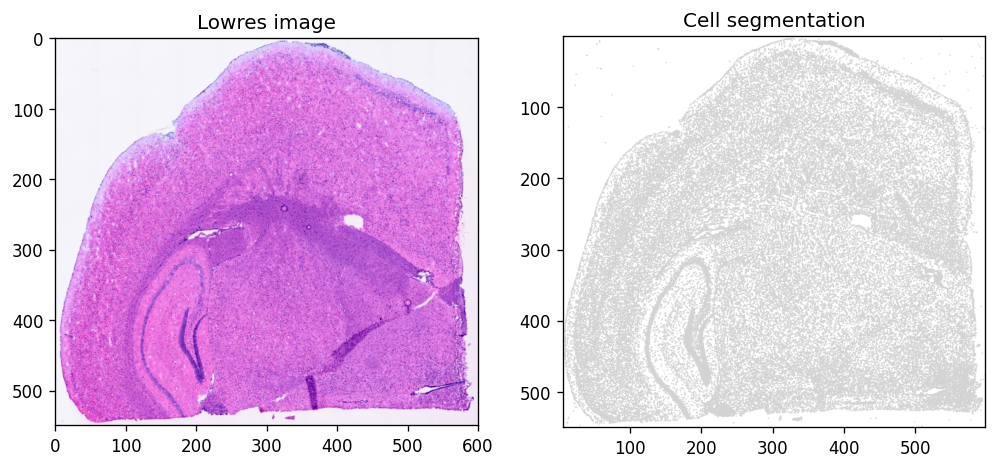

In [8]:
%%time
axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata.pl.render_images(f"{dataset_id}_lowres_image").pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[0], title="Lowres image"
)
sdata.pl.render_shapes(f"{dataset_id}_cell_segmentations").pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[1], title="Cell segmentation"
)

To visualize peak expression as an image, rasterize the spatial bins first:

In [9]:
%%time
for bin_size in ["016", "008", "002"]:
    # rasterize_bins() requires a compressed sparse column (csc) matrix
    sdata.tables[f"square_{bin_size}um"].X = sdata.tables[f"square_{bin_size}um"].X.tocsc()
    rasterized = rasterize_bins(
        sdata,
        f"{dataset_id}_square_{bin_size}um",
        f"square_{bin_size}um",
        "array_col",
        "array_row",
    )
    sdata[f"rasterized_{bin_size}um"] = rasterized

CPU times: user 6.19 s, sys: 1.76 s, total: 7.94 s
Wall time: 8.58 s


Then visualize a peak's global expression at 16µm resolution:

Using example feature: Map4:chr9:109912632-109913023:1
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


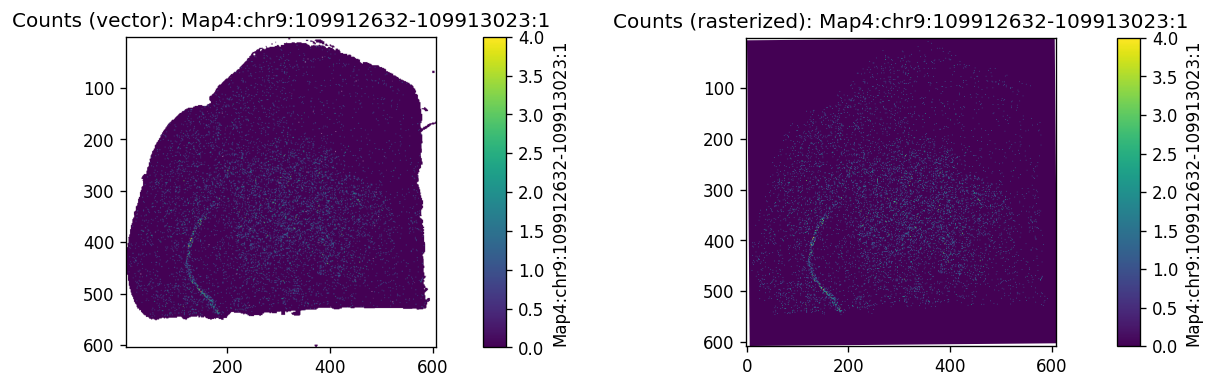

CPU times: user 8.53 s, sys: 4.56 s, total: 13.1 s
Wall time: 21.2 s


In [51]:
%%time
peak_name = 'Map4:chr9:109912632-109913023:1'
print(f"Using example feature: {peak_name}")

axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata.pl.render_shapes(f"{dataset_id}_square_016um", color=peak_name).pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[0], title=f"Counts (vector): {peak_name}"
)
sdata.pl.render_images(f"rasterized_016um", channel=peak_name).pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[1], title=f"Counts (rasterized): {peak_name}"
)
plt.subplots_adjust(wspace=1)
plt.show()

## Spatial variability testing with `SplisosmFFT`

To detect peak usage variation within a given gene, we run spatial variability test using `hsic-ir`.

### Data filtering and model setup

Peak filtering criteria:
- `min_counts`: minimum total UMI count across all bins.
- `min_bin_pct`: minimum fraction of bins in which a peak must be detected.
- Genes with fewer than two passing peaks are automatically excluded.

In [53]:
model = SplisosmFFT(neighbor_degree=1, rho=0.99)
model.setup_data(
    sdata=sdata,
    bins=test_bins_element,
    table_name=test_table,
    col_key="array_col",
    row_key="array_row",
    layer="counts",
    group_iso_by=group_iso_by, # 'gene_ids'
    gene_names=gene_name_col, # 'gene_ids'
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
)
print(model)

=== FFT SPLISOSM model for spatial isoform testings
- Number of genes: 1061
- Number of observed spots: 94592
- Number of raster cells: 134688
- Average number of isoforms per gene: 2.226201696512724
=== Test results
- Spatial variability test: NA
- Differential usage test: NA


Extract gene-level summary statistics:

In [54]:
%%time
gene_meta = model.extract_feature_summary(level='gene')
gene_meta.sort_values('perplexity', ascending=False).head(5)

Genes: 100%|██████████| 1061/1061 [00:01<00:00, 603.28it/s]

CPU times: user 1.78 s, sys: 290 ms, total: 2.07 s
Wall time: 2.12 s


,n_isos,perplexity,pct_bin_on,count_avg,count_std
gene,,,,,
Ppp3ca,6,4.951889,0.407138,0.869429,1.597794
Celf4,5,3.819581,0.202174,0.250539,0.552908
Homer1,4,3.788384,0.063769,0.070535,0.283515
Pcmt1,4,3.785652,0.139145,0.161441,0.432617
Rbbp6,4,3.780505,0.081297,0.087640,0.305624


Peak-level summary is also available:

In [55]:
peak_meta = model.extract_feature_summary(level='isoform')
peak_meta.sort_values('gene_ids', ascending=False).head(5)

,gene_ids,probe_ids,feature_types,CDS,Junctions,UTR3,UTR5,end,exon,genome,...,start,strand,width,pct_bin_on,count_total,count_avg,count_std,ratio_total,ratio_avg,ratio_std
mt-Nd5:chrM:12597-13503:1,mt-Nd5,mt-Nd5:chrM:12597-13503:1,Gene Expression,YES,no-junctions,,,13503,YES,,...,12597,+,907,0.295427,35035.0,0.370380,0.642801,0.672909,0.670371,0.432255
mt-Nd5:chrM:11870-13196:1,mt-Nd5,mt-Nd5:chrM:11870-13196:1,Gene Expression,YES,no-junctions,,,13196,YES,,...,11870,+,1327,0.135720,14026.0,0.148279,0.391148,0.269394,0.271458,0.408964
mt-Nd5:chrM:11742-12338:1,mt-Nd5,mt-Nd5:chrM:11742-12338:1,Gene Expression,YES,no-junctions,,,12338,YES,,...,11742,+,597,0.031123,3004.0,0.031757,0.178934,0.057697,0.058170,0.215502
mt-Nd4:chrM:11161-11413:1,mt-Nd4,mt-Nd4:chrM:11161-11413:1,Gene Expression,YES,no-junctions,,,11413,YES,,...,11161,+,253,0.906726,332118.0,3.511058,2.643438,0.937358,0.936997,0.150768
mt-Nd4:chrM:11100-11519:1,mt-Nd4,mt-Nd4:chrM:11100-11519:1,Gene Expression,YES,across-junctions,,,11519,YES,,...,11100,+,420,0.168820,17843.0,0.188631,0.443044,0.050359,0.050763,0.136139


### Running spatial variability test

In [56]:
%%time

model.test_spatial_variability(
    method="hsic-ir",
    ratio_transformation="none",
    n_jobs=-1,
    print_progress=True,
)
sv_res_16um = model.get_formatted_test_results("sv").sort_values("pvalue_adj")

SV (hsic-ir): 100%|██████████| 1061/1061 [00:16<00:00, 63.12it/s]


CPU times: user 31.8 s, sys: 5.82 s, total: 37.7 s
Wall time: 17.1 s


Top genes, sorted by adjusted p-value:

In [57]:
sig_001 = int((sv_res_16um["pvalue_adj"] < 0.01).sum())
print(
    "Spatially variably processed genes (FDR < 0.01, 16um): "
    f"{sig_001} out of {sv_res_16um.shape[0]} total genes"
)
sv_res_16um.head(5)

Spatially variably processed genes (FDR < 0.01, 16um): 501 out of 1061 total genes


,gene,statistic,pvalue,pvalue_adj
357,Gls,6.126092e-07,0.0,0.0
293,Ensa,1.468206e-06,0.0,0.0
340,Gabbr1,2.055658e-06,0.0,0.0
77,Arpp21,2.619232e-06,0.0,0.0
85,Atp1b1,2.350605e-06,0.0,0.0


Merge gene-level summary back into results:

In [58]:
sv_res_16um.merge(
    gene_meta.reset_index()[['gene', 'n_isos', 'perplexity', 'pct_bin_on']],
    on='gene',
    how='left',
).head(5)

,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on
0,Gls,6.126092e-07,0.0,0.0,2,1.514386,0.124408
1,Ensa,1.468206e-06,0.0,0.0,3,2.289981,0.177774
2,Gabbr1,2.055658e-06,0.0,0.0,4,2.846700,0.229692
3,Arpp21,2.619232e-06,0.0,0.0,4,2.701563,0.154178
4,Atp1b1,2.350605e-06,0.0,0.0,4,2.129971,0.463348


## Visualize significant events

The helper below renders per-peak **log1p counts** and **within-gene ratios** on the testing grid.

In [59]:
def ensure_rasterized(sdata, bin_table: str, bin_element: str, layer: str = "counts"):
    raster_key = f"rasterized_{bin_table}_{layer}"
    if raster_key in sdata.images:
        return raster_key

    adata = sdata.tables[bin_table]
    adata.X = adata.layers[layer]
    if hasattr(adata.X, "tocsc") and getattr(adata.X, "format", None) != "csc":
        adata.X = adata.X.tocsc()

    sdata[raster_key] = rasterize_bins(
        sdata,
        bins=bin_element,
        table_name=bin_table,
        col_key="array_col",
        row_key="array_row",
    )
    return raster_key

The plotting function checks peak availability, lazily rasterizes data on demand, computes log1p counts and within-gene ratios, and optionally masks zero values.

In [60]:
def plot_gene_peak_maps(
    sdata,
    bin_table: str,
    bin_element: str,
    gene_id: str,
    peak_meta: pd.DataFrame | None = None,
    group_col: str = "gene_ids",
    max_peaks: int = 4,
    hide_zero_count: bool = True,
    hide_zero_ratio: bool = True,
):
    adata = sdata.tables[bin_table]
    if peak_meta is None:
        peak_meta = adata.var.copy()

    if group_col not in peak_meta.columns:
        raise ValueError(f"'{group_col}' not found in peak_meta columns")

    peak_names = peak_meta.index[
        peak_meta[group_col].astype(str) == str(gene_id)
    ].tolist()
    if len(peak_names) == 0:
        raise ValueError(f"No peaks found for gene id '{gene_id}'")
    if any(peak not in adata.var_names for peak in peak_names):
        raise ValueError(f"Some peaks not found in {bin_table}.var_names")
    n_peaks = len(peak_names)
    n_shown = min(n_peaks, max_peaks)
    peak_names = peak_names[:n_shown]

    raster_key = ensure_rasterized(sdata, bin_table=bin_table, bin_element=bin_element)
    data = sdata[raster_key].sel(c=peak_names).values
    counts_cube = np.moveaxis(np.asarray(data, dtype=float), 0, -1)

    counts_flat = counts_cube.reshape(-1, counts_cube.shape[-1])
    ratios_flat = counts_to_ratios(counts_flat, transformation="none", nan_filling="none")
    ratios_cube = ratios_flat.numpy().reshape(counts_cube.shape)

    n_peak = counts_cube.shape[-1]
    fig, axes = plt.subplots(2, n_peak, figsize=(4 * n_peak, 7), squeeze=False)

    for i, peak in enumerate(peak_names):
        c = counts_cube[:, :, i]
        r = ratios_cube[:, :, i]
        if hide_zero_count:
            c = np.where(c == 0, np.nan, c)
        if hide_zero_ratio:
            r = np.where(r == 0, np.nan, r)

        im0 = axes[0, i].imshow(np.log1p(c), cmap="Purples", vmin=0.0)
        axes[0, i].set_title(f"Count (log1p)\n{peak}")
        axes[0, i].axis("off")
        fig.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

        vmax = np.nanpercentile(ratios_cube, 99) if np.isfinite(ratios_cube).any() else 1.0
        im1 = axes[1, i].imshow(r, cmap="Reds", vmin=0.0, vmax=vmax)
        axes[1, i].set_title(f"Ratio\n{peak}")
        axes[1, i].axis("off")
        fig.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

    fig.suptitle(f"Gene {gene_id} | showing {n_shown}/{n_peaks} peaks | {bin_table}", y=1)
    fig.tight_layout()
    plt.show()

In [61]:
top_genes = sv_res_16um.head(10)["gene"].astype(str).tolist()
top_genes[:5]

['Gls', 'Ensa', 'Gabbr1', 'Arpp21', 'Atp1b1']

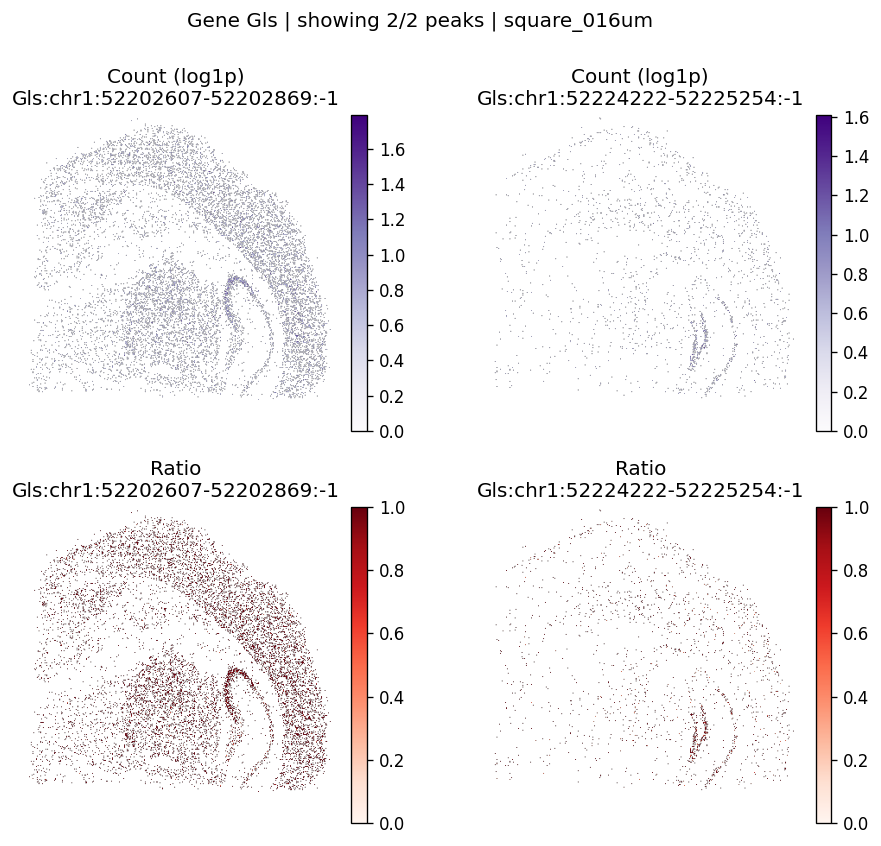

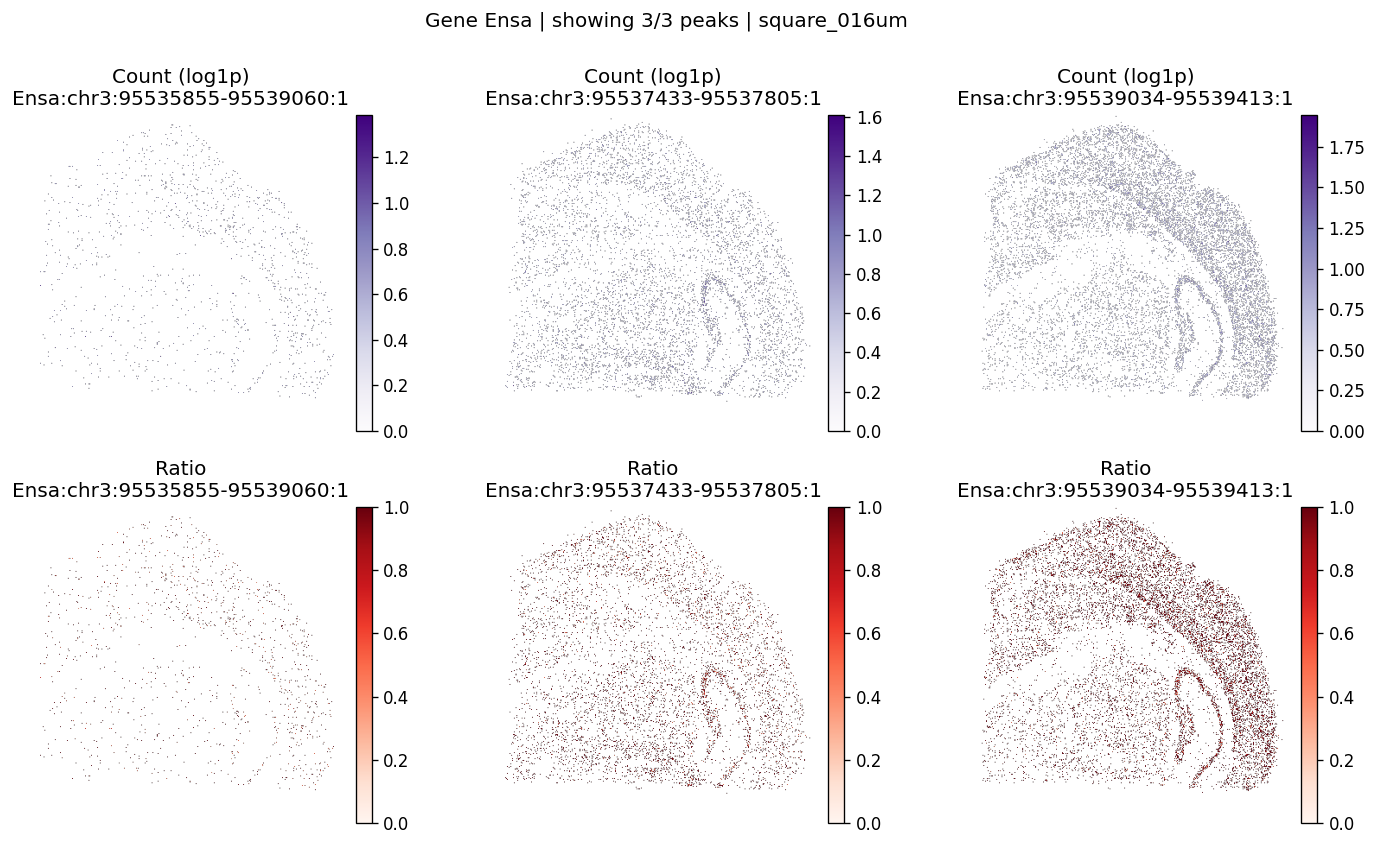

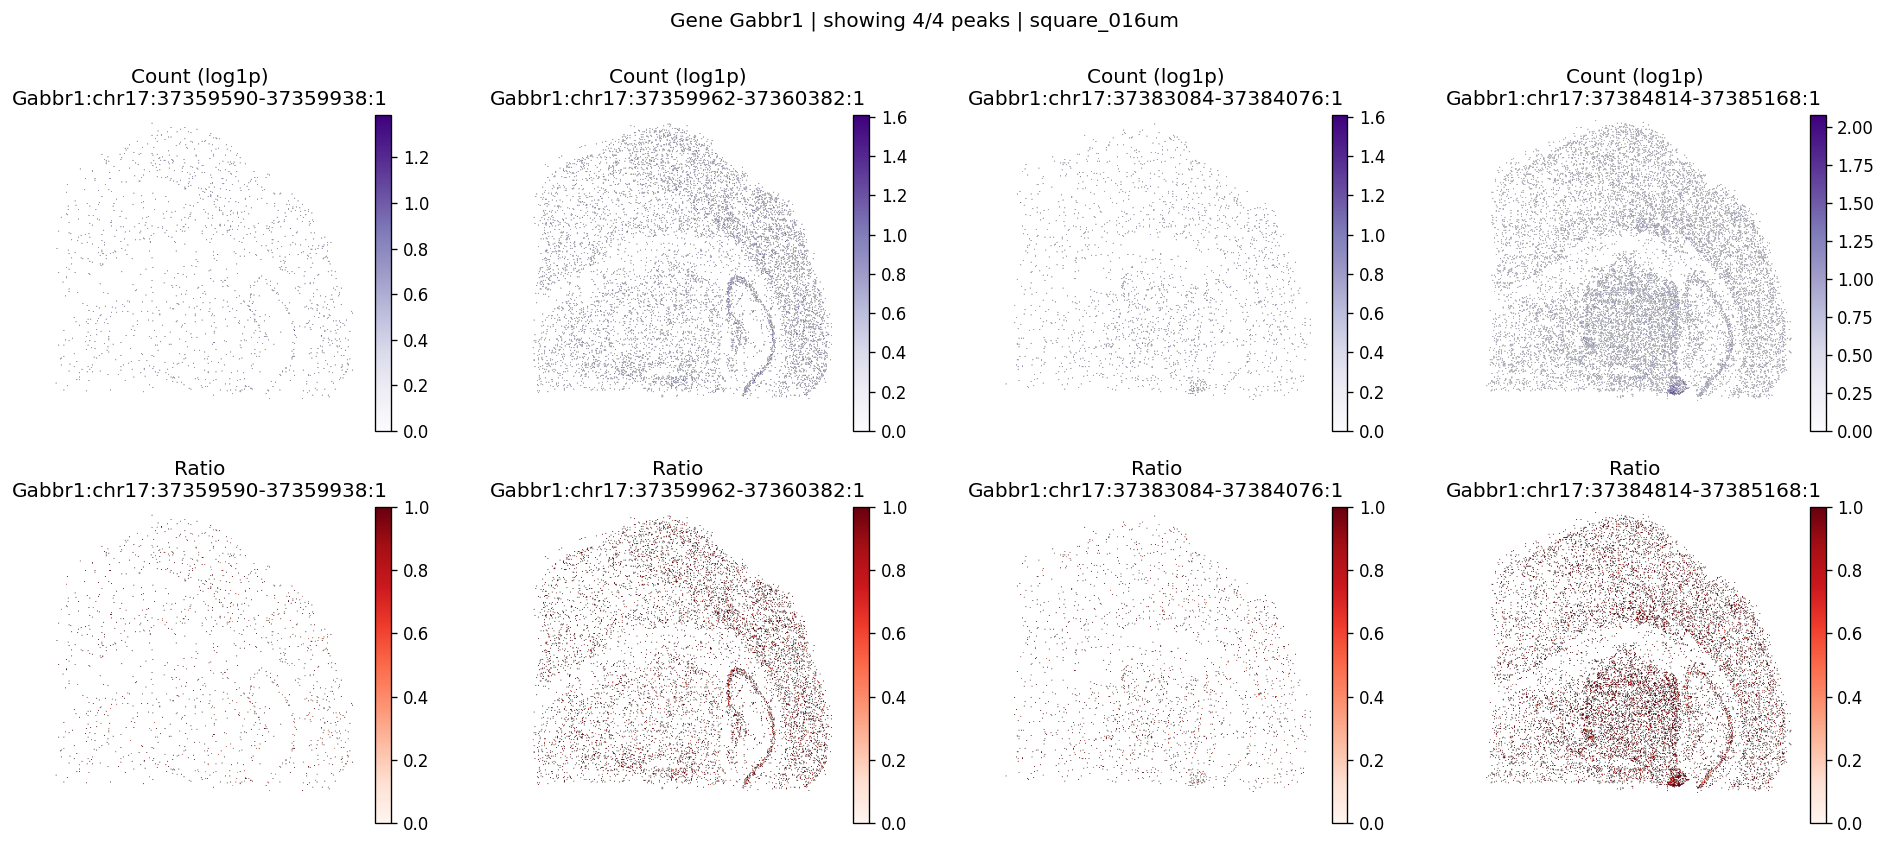

In [62]:
for gene_id in top_genes[:3]:
    plot_gene_peak_maps(
        sdata=sdata,
        bin_table=test_table,
        bin_element=test_bins_element,
        gene_id=gene_id,
        group_col='gene_ids',
        max_peaks=6,
        peak_meta=peak_meta,
        hide_zero_ratio=True,
    )

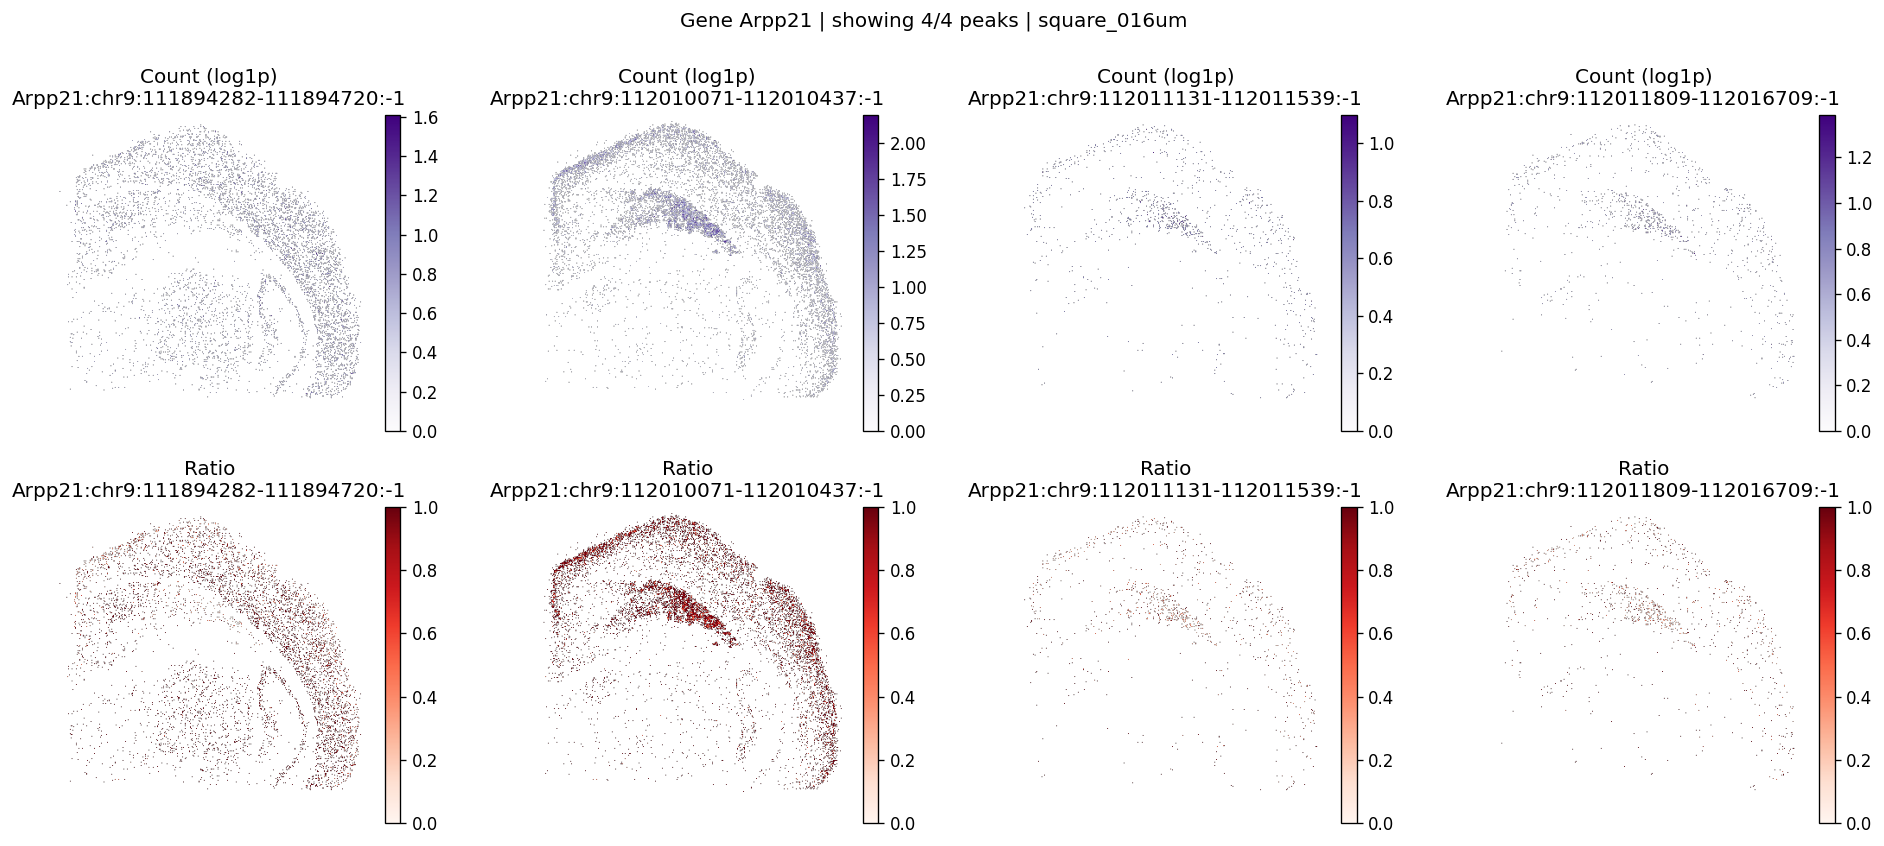

CPU times: user 446 ms, sys: 35.6 ms, total: 482 ms
Wall time: 483 ms


In [63]:
%%time
# Example: inspect a specific gene manually
plot_gene_peak_maps(
    sdata, test_table, test_bins_element, 
    gene_id="Arpp21", 
    group_col='gene_ids', 
    peak_meta=peak_meta
)

## Advanced analyses

### Spatial resolution comparison

For illustration, we use the top 200 genes from the 16µm analysis as the reference set:

In [ ]:
# np.random.seed(42)
# gene_names = sdata.tables[test_table].var['gene_ids'].unique()
# gene_subset = np.random.choice(gene_names, size=500, replace=False)
gene_subset = sv_res_16um.sort_values('pvalue').head(500)['gene'].astype(str).tolist()

Run spatial variability tests across all three resolutions:

In [40]:
%%time
# Compare results across 2µm, 8µm, 16µm resolutions
resolutions = [
    {'bin': f'{dataset_id}_square_002um', 'table_name': 'square_002um'},
    {'bin': f'{dataset_id}_square_008um', 'table_name': 'square_008um'},
    {'bin': f'{dataset_id}_square_016um', 'table_name': 'square_016um'},
]

res_results = []
for res in resolutions:
    m = SplisosmFFT(neighbor_degree=1, rho=0.99)
    sdata_subset = sd.filter_by_table_query(
        sdata,
        table_name=res['table_name'],
        var_expr=an.col(gene_name_col).is_in(gene_subset),
    )
    m.setup_data(
        sdata_subset,
        bins=res['bin'],
        table_name=res['table_name'],
        col_key="array_col",
        row_key="array_row",
        layer="counts",
        group_iso_by=group_iso_by,
        gene_names=gene_name_col,
        min_counts=min_counts,
        min_bin_pct=0.0
    )
    m.test_spatial_variability(method='hsic-ir')
    results = m.get_formatted_test_results('sv')[['gene', 'pvalue']].copy()
    results.rename(columns={'pvalue': f"p_{res['table_name']}"}, inplace=True)
    res_results.append(results)

SV (hsic-ir): 100%|██████████| 500/500 [00:07<00:00, 68.97it/s]


CPU times: user 24min 30s, sys: 31min 2s, total: 55min 33s
Wall time: 21min 10s


In [41]:
merged = res_results[0]
for res in res_results[1:]:
    merged = merged.merge(res, on="gene", how="inner")

p_cols = [c for c in merged.columns if c.startswith("p_")]
print("Spearman correlation across spatial resolutions:")
display(merged[p_cols].corr(method="spearman"))

Spearman correlation across spatial resolutions:


,p_square_002um,p_square_008um,p_square_016um
p_square_002um,1.000000,0.755450,0.625206
p_square_008um,0.755450,1.000000,0.901805
p_square_016um,0.625206,0.901805,1.000000


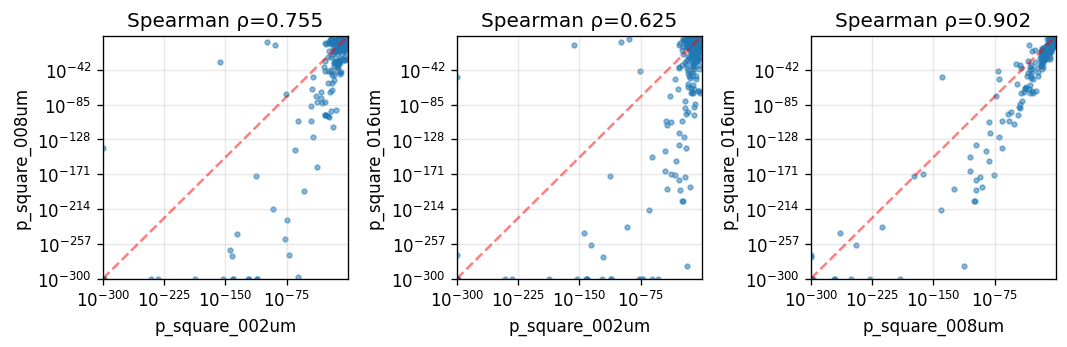

In [44]:
pairs = list(combinations(p_cols, 2))
if pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(3 * len(pairs), 3), squeeze=False)
    axes = axes.ravel()

    for ax, (x_col, y_col) in zip(axes, pairs):
        x = merged[x_col].to_numpy()
        y = merged[y_col].to_numpy()
        corr, pval = spearmanr(x, y)

        ax.scatter(x + 1e-300, y + 1e-300, s=8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"Spearman ρ={corr:.3f}")
        ax.grid(True, alpha=0.3)

        low = 1e-300
        high = max(np.max(x), np.max(y))
        ax.plot([low, high], [low, high], "r--", alpha=0.5, linewidth=1.5)
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

    plt.tight_layout()
    plt.show()

Gene rankings are broadly consistent across resolutions, especially between 16µm and 8µm. The 2µm analysis shows stronger statistical significance, likely because the kernel places more weight on low-frequency patterns at finer scales.

### Method comparison: `SplisosmFFT` vs `SplisosmNP`

Compare FFT-accelerated and non-parametric spatial variability tests at 16 µm resolution.

`SplisosmNP.setup_data` performs low-rank kernel approximation (controlled by `approx_rank`). A higher rank gives more accurate approximations at increased cost. Here we use `approx_rank=20` for demonstration.

In [45]:
%%time
# Run SplisosmNP at 16µm for direct comparison with SplisosmFFT
model_np = SplisosmNP()
model_np.setup_data(
    adata=sdata.tables[test_table],
    spatial_key='spatial', # adata.obsm key for spatial coordinates
    layer='counts',
    approx_rank=20,
    group_iso_by=group_iso_by, # 'gene_ids'
    gene_names=gene_name_col, # 'gene_ids'
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
)

CPU times: user 2min 4s, sys: 6.09 s, total: 2min 10s
Wall time: 1min 15s


In [46]:
%%time
model_np.test_spatial_variability(
    method='hsic-ir',
    ratio_transformation='none',
    print_progress=True,
)

100%|██████████| 1061/1061 [00:02<00:00, 397.27it/s]

CPU times: user 3.9 s, sys: 498 ms, total: 4.4 s
Wall time: 2.68 s


Compare p-values between `SplisosmFFT` and `SplisosmNP`:

In [47]:
# Extract results and merge
sv_np = model_np.get_formatted_test_results('sv')[['gene', 'pvalue']].copy()
sv_np = sv_np.rename(columns={'pvalue': 'pvalue_np'})

comparison = sv_res_16um[['gene', 'pvalue']].copy()
comparison = comparison.rename(columns={'pvalue': 'pvalue_fft'})
comparison = comparison.merge(sv_np, on='gene', how='inner')

corr, _ = spearmanr(comparison['pvalue_fft'], comparison['pvalue_np'])

print(f'Genes tested in both methods: {len(comparison)}')
print(f'== Significant in SplisosmFFT (FDR < 0.01): {(comparison["pvalue_fft"] < 0.01).sum()}')
print(f'== Significant in SplisosmNP (FDR < 0.01): {(comparison["pvalue_np"] < 0.01).sum()}')
print(f'== P-value correlation (Spearman rho): {corr:.4f}')

Genes tested in both methods: 1061
== Significant in SplisosmFFT (FDR < 0.01): 537
== Significant in SplisosmNP (FDR < 0.01): 620
== P-value correlation (Spearman rho): 0.7945


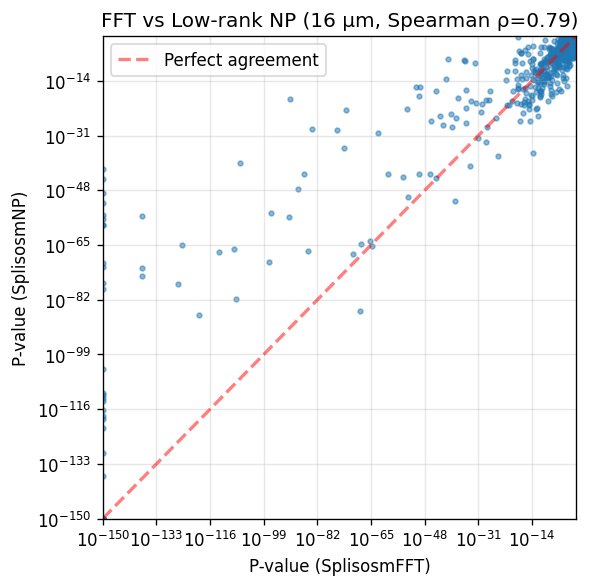

In [48]:
# Scatter plot comparison
fig, ax = plt.subplots(figsize=(5, 5))
x = comparison['pvalue_fft'].to_numpy()
y = comparison['pvalue_np'].to_numpy()

ax.scatter(x + 1e-150, y + 1e-150, s=8, alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('P-value (SplisosmFFT)')
ax.set_ylabel('P-value (SplisosmNP)')
ax.set_title(f'FFT vs Low-rank NP (16 µm, Spearman ρ={corr:.2f})')
ax.grid(True, alpha=0.3)

# Add diagonal reference line
lims = [1e-150, 1.0]
ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect agreement', linewidth=2)
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

### Summary and recommendations

**Key findings:**

1. **Spatial variability is robustly detectable** in this Visium HD 3' peak-level dataset using `SplisosmFFT` on regular grids.

2. **Spatial resolution trade-offs:**
   - **16 um**: Fast and reliable - recommended for initial exploration.
   - **8 um**: High agreement with 16 um results.
   - **2 um**: Highest resolution but slower and sparser.

3. **Method equivalence:** `SplisosmFFT` and `SplisosmNP` yield concordant rankings on regular grids, particularly for genes with strong spatial patterns.

**Recommendations:**

- Start with **16 um** binning for exploratory analysis.
- Refine with **8 um** if finer spatial detail is needed.
- Use **SplisosmFFT** on regular grids (Visium HD, Xenium binned data) with `neighbor_degree=1, rho=0.99` as a robust default.
- Use **SplisosmNP** for irregular geometries (e.g., cell-segmented data).

## For reproducibility

In [49]:
import sys
from datetime import date
import splisosm

print("Last updated:", date.today())
print("Python:", sys.version.split()[0])
print("splisosm:", getattr(splisosm, "__version__", "unknown"))

Last updated: 2026-03-17
Python: 3.12.12
splisosm: 1.0.4
